In [2]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import time as t
from PIL import Image

In [ ]:
core = openmc.Material(1, "core", temperature=294)
# Add nuclides to core
core.add_nuclide('Pu239', 0.94, "wo")
core.add_nuclide('Pu240', 0.05, "wo")
core.add_nuclide('Ga69', 0.01, "wo")
core.set_density('g/cm3', 15.7)

coreCoating = openmc.Material(2, "Coat", temperature=294)
coreCoating.add_nuclide('Ni58', 1, "wo")
coreCoating.set_density('g/cm3', 8.9)

#shield
brick = openmc.Material(3, "brick", temperature=294)
brick.add_nuclide('W186', 0.5*0.284, "ao")
brick.add_nuclide('W184', 0.5*0.308, "ao")
brick.add_nuclide('W183', 0.5*0.143, "ao")
brick.add_nuclide('W182', 0.5*0.265, "ao")

brick.add_nuclide('C0', 0.5, "ao")
brick.set_density('g/cm3',  15.6)

#luft
air = openmc.Material(4, "air")
air.add_nuclide('N14', 0.78, "ao")
air.add_nuclide('O16', 0.21, "ao")
air.add_nuclide('Ar40', 0.1, "ao")
air.set_density('g/cm3', 0.001225*1e-3)

#creating Materials() and exporting to xml
mats = openmc.Materials([core, coreCoating, brick, air])
mats.export_to_xml()


/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=1.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=2.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=3.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=4.
  warn(msg, IDWarning)


In [ ]:
openmc.config['cross_sections'] = "" #Path to cross section data

(Universe
 	ID             =	2
 	Name           =	
 	Geom           =	CSG
 	Cells          =	[1, 2, 5, 3, 4],
 [-15, 15],
 [-15, 20])

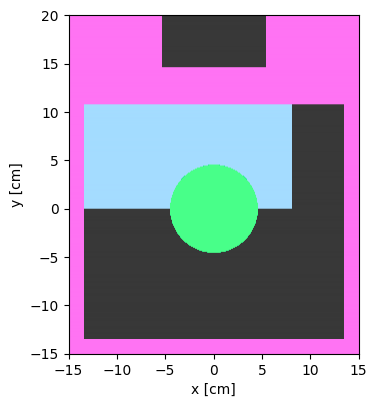

In [ ]:
colors = {
        1: (9, 255, 0),#"#09FF00",
        2: (56, 56, 56),#"#373737",
        3: (164, 220, 255),#"#a1abb1",
        4: (255, 115, 243),#"#ff73f3",
        5: (56, 56, 56),#"#a1abb1",
    }

def makeCore(h, plot=True, sides=4):
    coreR = 4.55 #4.55


    inCore = openmc.Sphere(r=coreR-0.0127)
    outCore = openmc.Sphere(r=coreR)
    coreSplitT = openmc.YPlane(y0=0.0127)
    coreSplitB = openmc.YPlane(y0=-0.0127)




    pitch = 30

    left = openmc.XPlane(x0=-(pitch)/2, boundary_type='vacuum')
    right = openmc.XPlane(x0=(pitch)/2, boundary_type='vacuum')
    bottom = openmc.YPlane(y0=-(pitch)/2, boundary_type='vacuum')
    top = openmc.YPlane(y0=(pitch+11)/2, boundary_type='vacuum')
    back = openmc.ZPlane(z0=-(pitch)/2, boundary_type='vacuum')
    front = openmc.ZPlane(z0=(pitch)/2, boundary_type='vacuum')

    H = 2.125*2.54*2
    rightI = openmc.XPlane(x0=10.625*2.54/2 - 2.125*2.54)
    bottomI = openmc.YPlane(y0=0)
    backI = openmc.ZPlane(z0=-10.625*2.54/2 + 2.125*2.54)

    leftO = openmc.XPlane(x0=-10.625*2.54/2)
    rightO = openmc.XPlane(x0=10.625*2.54/2)
    bottomO = openmc.YPlane(y0=-4.25*2.54*1.25)
    topO = openmc.YPlane(y0=H)
    backO = openmc.ZPlane(z0=-10.625*2.54/2)
    frontO = openmc.ZPlane(z0=10.625*2.54/2)

    rightB = openmc.XPlane(x0=2.125*2.54)
    leftB = openmc.XPlane(x0=-2.125*2.54)
    bottomB = openmc.YPlane(y0=h+coreR)
    topB = openmc.YPlane(y0=h+coreR + 2.125*2.54)
    backB = openmc.ZPlane(z0=-2.125*2.54/2)
    frontB = openmc.ZPlane(z0=2.125*2.54/2)

    if(sides == 4):
        frontI = openmc.ZPlane(z0=10.625*2.54/2 - 2.125*2.54)
        leftI = openmc.XPlane(x0=-10.625*2.54/2 + 2.125*2.54)
    elif(sides == 3):
        frontI = frontO
        leftI = openmc.XPlane(x0=-10.625*2.54/2 + 2.125*2.54)
    else:
        frontI = frontO
        leftI = leftO


    coreCell = openmc.Cell(11)
    coreCell.fill = core
    coreCell.region = -inCore & (+coreSplitT | -coreSplitB)

    coatCell = openmc.Cell(10)
    coatCell.fill = coreCoating
    coatCell.region = +left & -right & +bottom & -top & (+inCore | (-inCore & -coreSplitT & +coreSplitB))

    coreCoatCell = openmc.Cell(1, fill=openmc.Universe(cells=[coreCell, coatCell]), region=-outCore)



    shieldCell = openmc.Cell(2)
    shieldCell.fill = brick
    shieldCell.region = +leftO & -rightO & +bottomO & -topO & -frontO & +backO & (-bottomI | +frontI | -leftI | +rightI | -backI) & +outCore

    moderator = openmc.Cell(3)
    moderator.fill = air
    moderator.region = +leftI & -rightI & +bottomI & -topO & -frontI & +backI & +outCore  & (-bottomB | +topB | -leftB | +rightB | +frontB | -backB)

    boundBox = openmc.Cell(4)
    boundBox.fill = air
    boundBox.region = +left & -right & +bottom & -top & -front & +back & (-bottomO | +topO | -leftO | +rightO | +frontO | -backO) & (-bottomB | +topB | -leftB | +rightB | +frontB | -backB)


    brickCell = openmc.Cell(5)
    brickCell.fill = brick
    brickCell.region = +leftB & -rightB & +bottomB & -topB & -frontB & +backB


    root = openmc.Universe(cells=[coreCoatCell, shieldCell, brickCell, moderator, boundBox])



    geom = openmc.Geometry()
    geom.root_universe = root
    geom.export_to_xml()

    # root.plot(basis='xy')
    # root.plot(basis='yz')
    # root.plot(basis='xz')

    if(plot): 
        ax = root.plot(
            colors = colors, 
            pixels = 100000,
            # background = (164, 220, 255)
            )
        ax.set_xlim(-15, 15)
        ax.set_ylim(-15, 20)
    return root, geom, [-15, 15], [-15, 20]

makeCore(10, sides=2)

/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=11.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=10.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=2.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=3.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=4.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/o

(Universe
 	ID             =	4
 	Name           =	
 	Geom           =	CSG
 	Cells          =	[1, 2, 5, 3, 4],
 [-15, 15],
 [-15, 20])

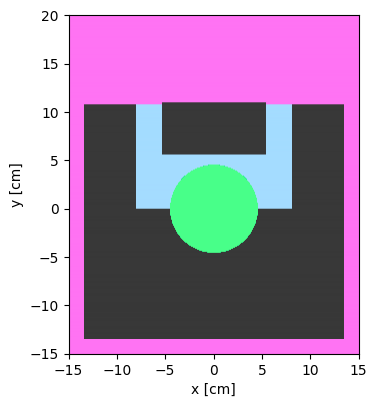

In [6]:
makeCore(1)
# makeCore(20)
# makeCore(30)
# makeCore(40)
# makeCore(50)

In [7]:
point = openmc.stats.Point((0, -0.1, 0))
src = openmc.IndependentSource(space=point)

settings = openmc.Settings()
settings.source = src
settings.batches = 100
settings.inactive = 10
settings.particles = 8000
settings.export_to_xml()

/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=11.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=10.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=2.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=3.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=4.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/o

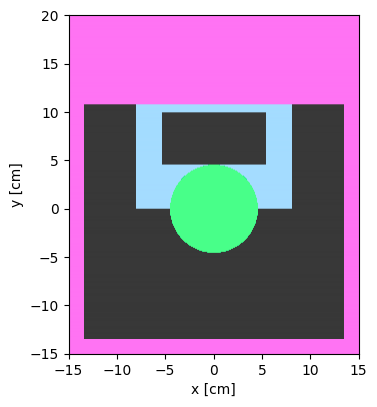

In [19]:
r, geom, xLim, yLim = makeCore(0, sides=4)


In [7]:
def makeTally():
    tallies_file = openmc.Tallies()

    mesh = openmc.RegularMesh()
    mesh.dimension = [200, 200]
    mesh.lower_left = [xLim[0], yLim[0]]
    mesh.upper_right = [xLim[1], yLim[1]]

    # Create mesh filter for tally
    mesh_filter = openmc.MeshFilter(mesh)

    # Create mesh tally to score flux and fission rate
    tally = openmc.Tally(name='flux')
    tally.filters = [mesh_filter]
    tally.scores = ['flux', 'fission']
    tallies_file.append(tally)

    tallies_file.export_to_xml()
makeTally()

In [26]:
import os
os.system('rm s*h5')

openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [15]:
sp = openmc.StatePoint('statepoint.100.h5')
keff = sp.keff.nominal_value
keff_error = sp.keff.std_dev
print(keff,keff_error)

0.8674614506893409 0.002098868183134152


Text(0.5, 0.98, '$k_{eff}$ = 0.88667 ± 0.00071')

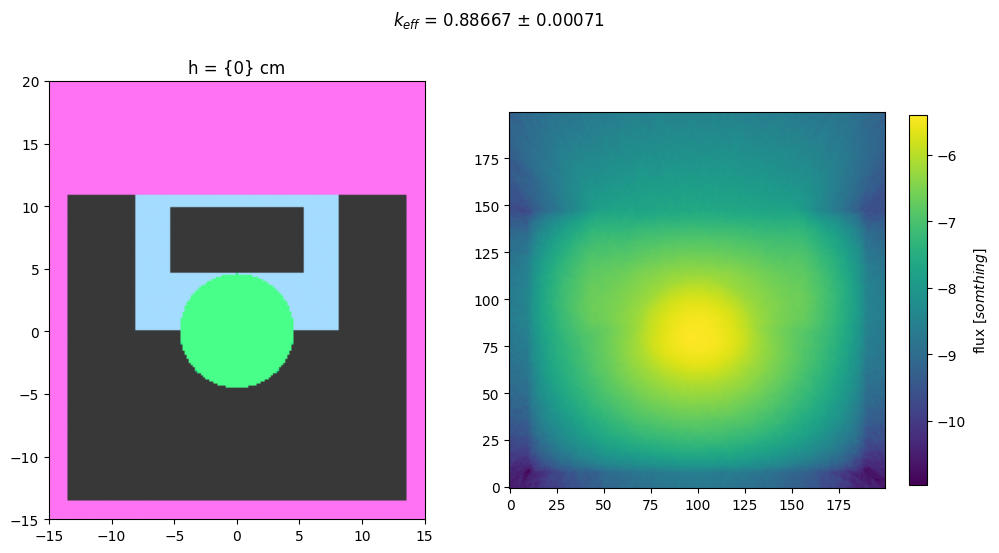

In [12]:
tally = sp.get_tally(scores=['flux'])

flux = tally.get_slice(scores=['flux'])
# fission = tally.get_slice(scores=['fission'])

flux.std_dev.shape = (200, 200)
flux.mean.shape = (200, 200)

maxFlux = np.max(np.log(flux.mean))

fig, ax = plt.subplots(1, 2, figsize=(12, 6), width_ratios=[0.8, 1])
geom.plot(axes=ax[0], colors=colors)
ax[0].set_xlim(xLim)
ax[0].set_ylim(yLim)
ax[0].set_title("h = {0} cm")
img = ax[1].imshow(np.log(flux.mean))
# ax[1].imshow(1/(1-np.log(flux.mean)))
ax[1].invert_yaxis()
cbar = plt.colorbar(img, shrink=0.8)
cbar.set_label("flux $[somthing]$")
fig.suptitle("$k_{eff}$ = " + f"{round(keff,5)} ± {round(keff_error,5)}")

/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=11.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=10.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=2.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=3.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=4.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/o

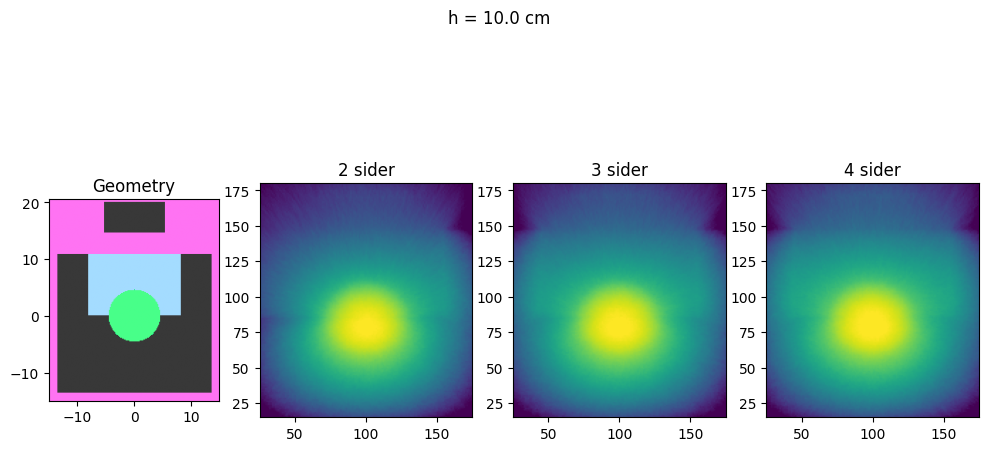

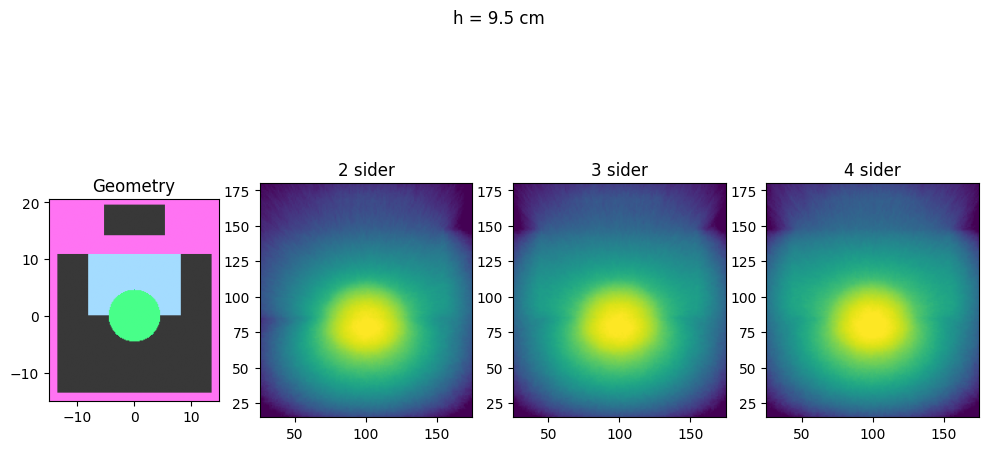

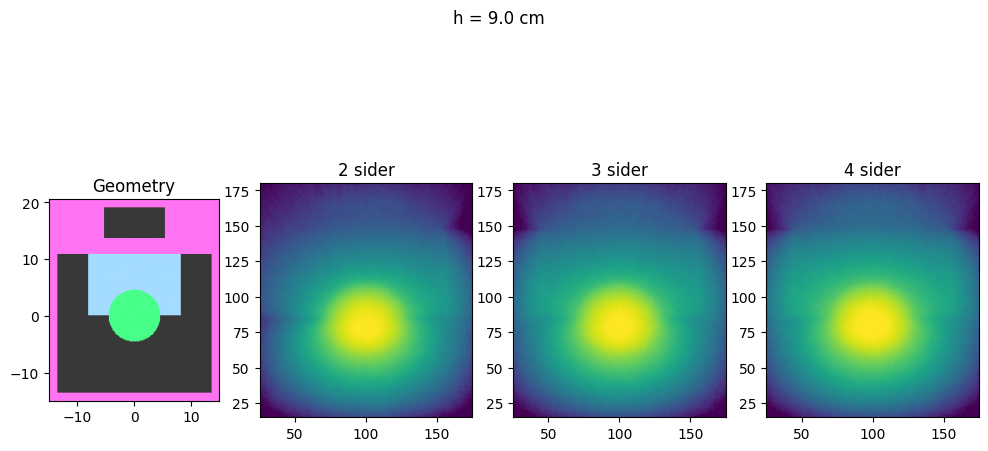

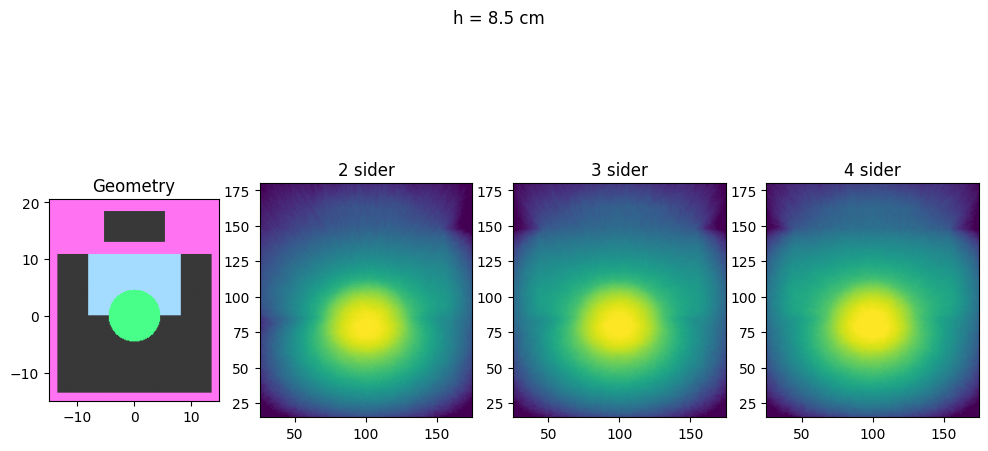

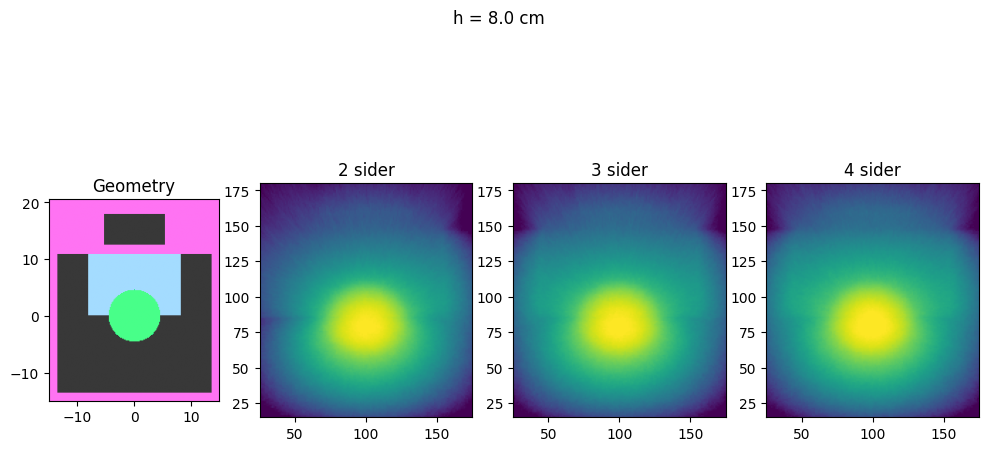

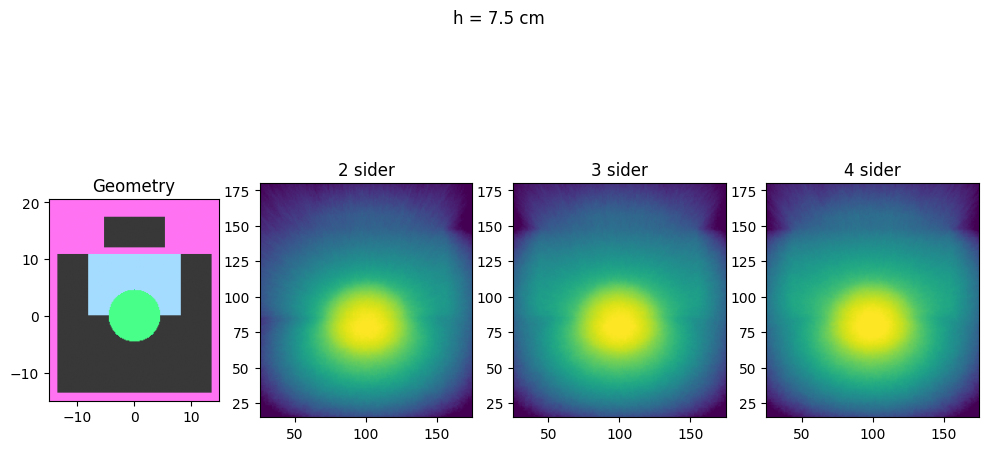

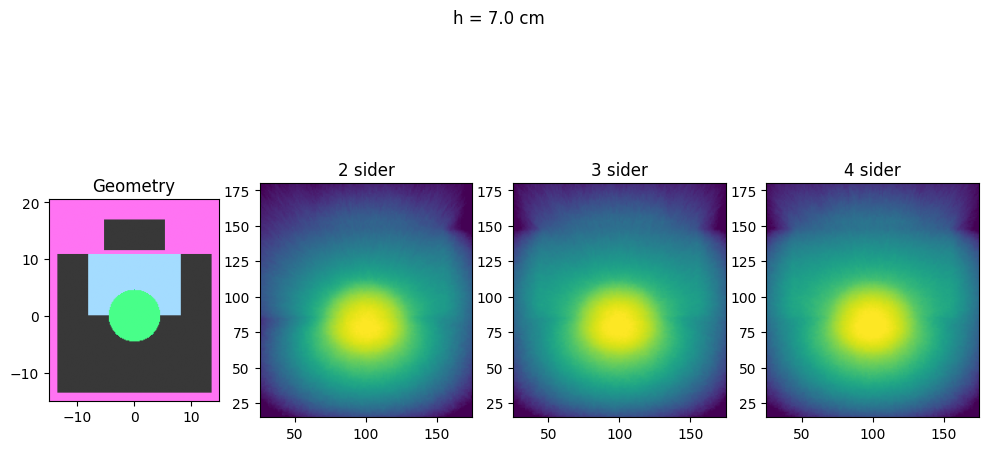

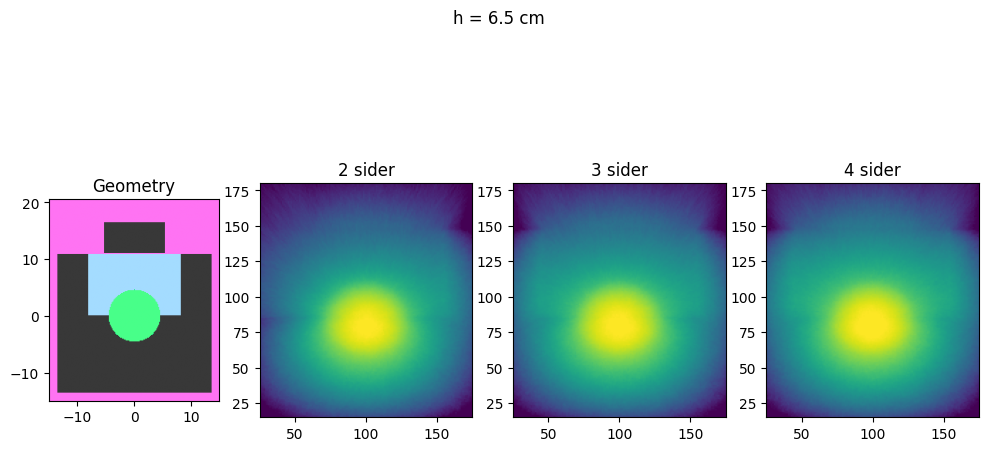

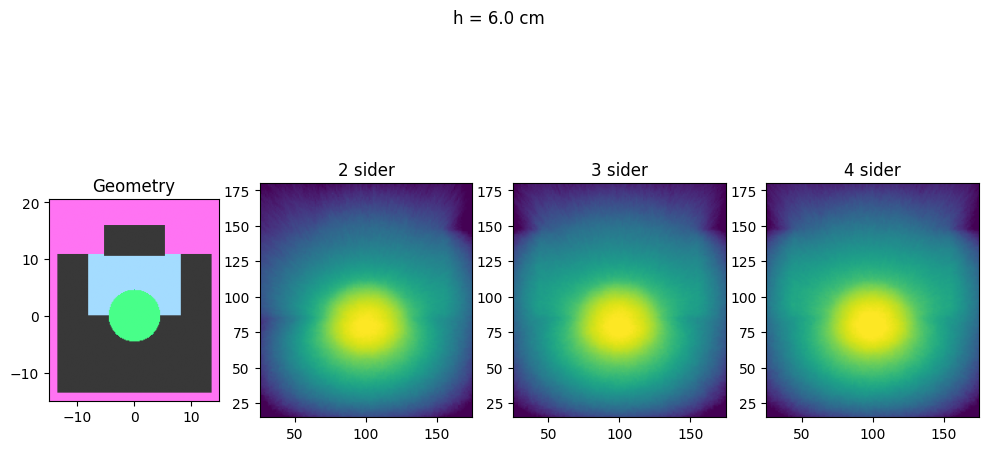

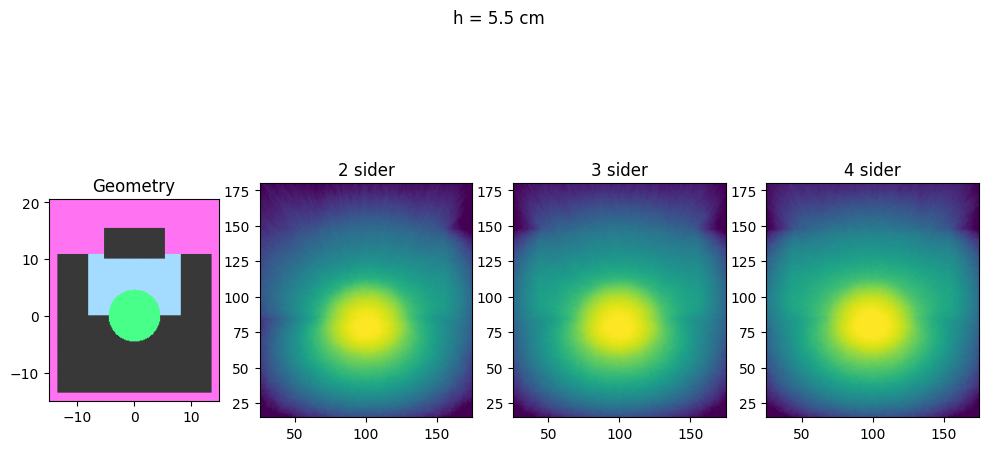

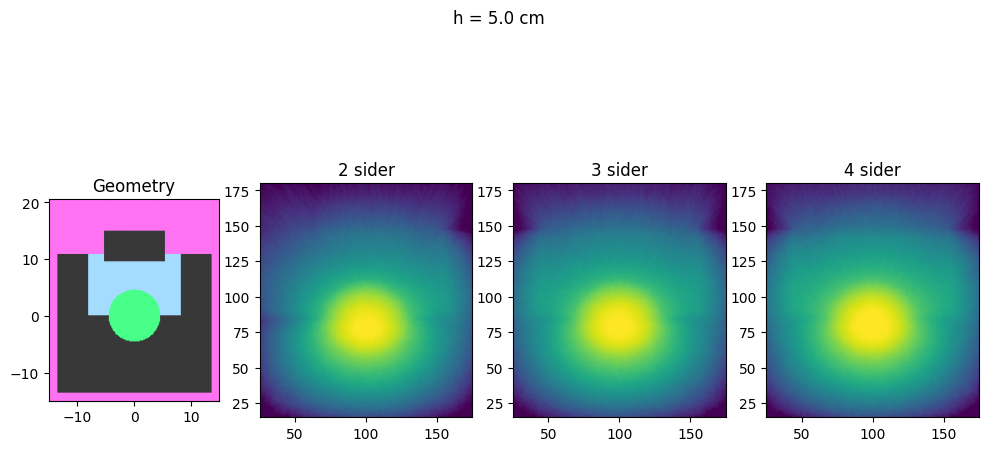

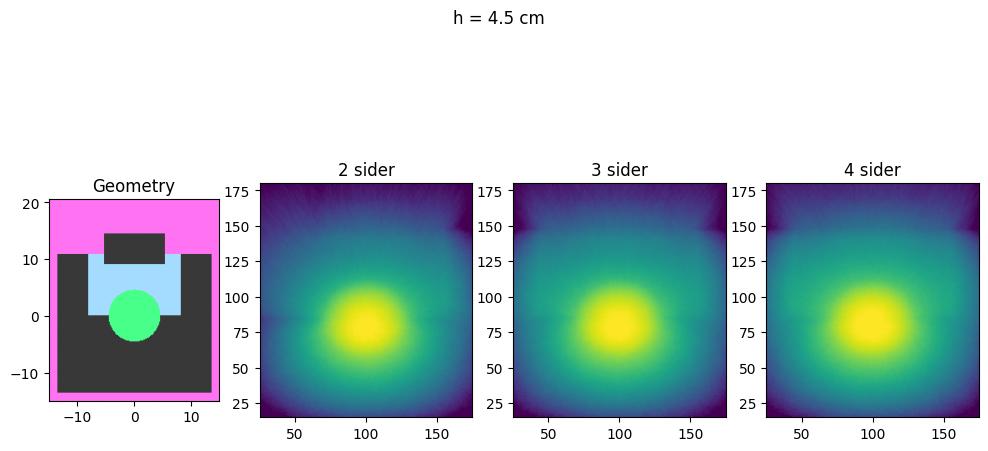

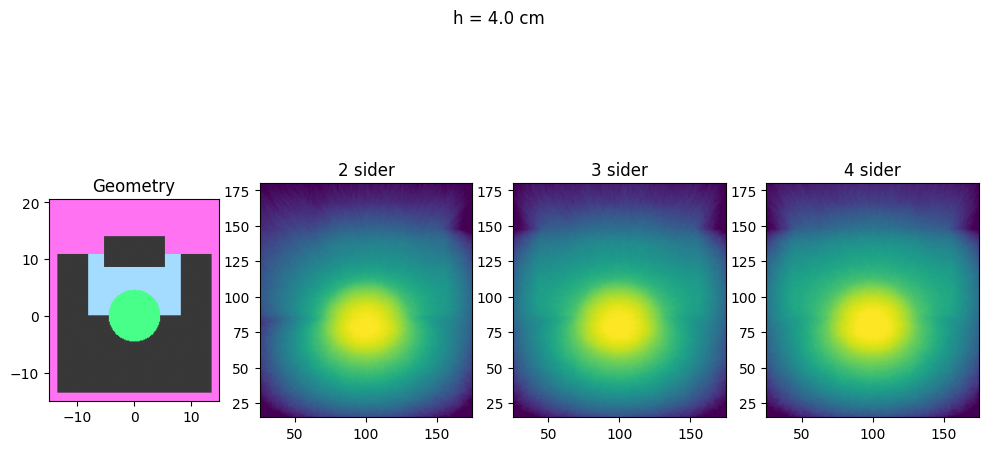

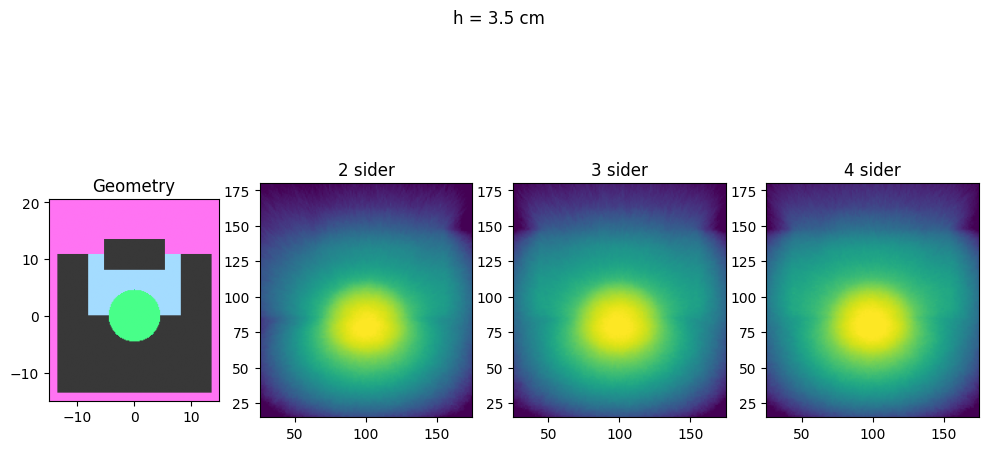

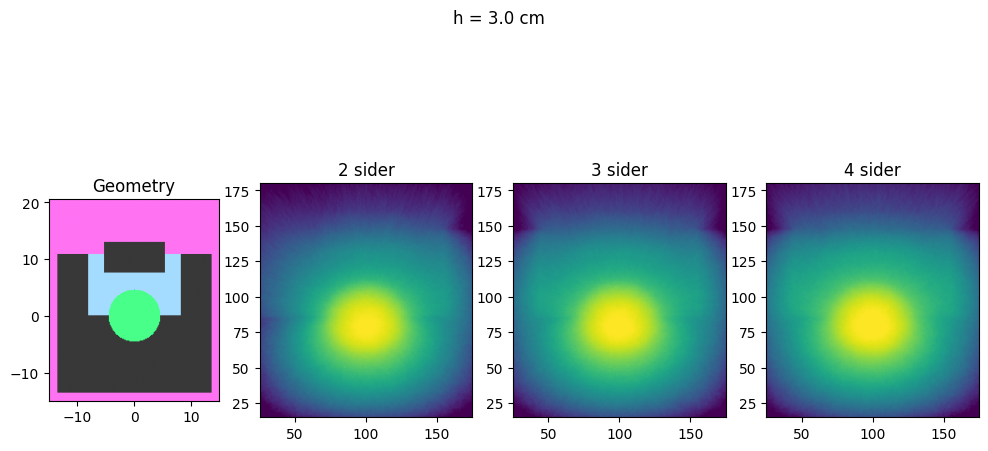

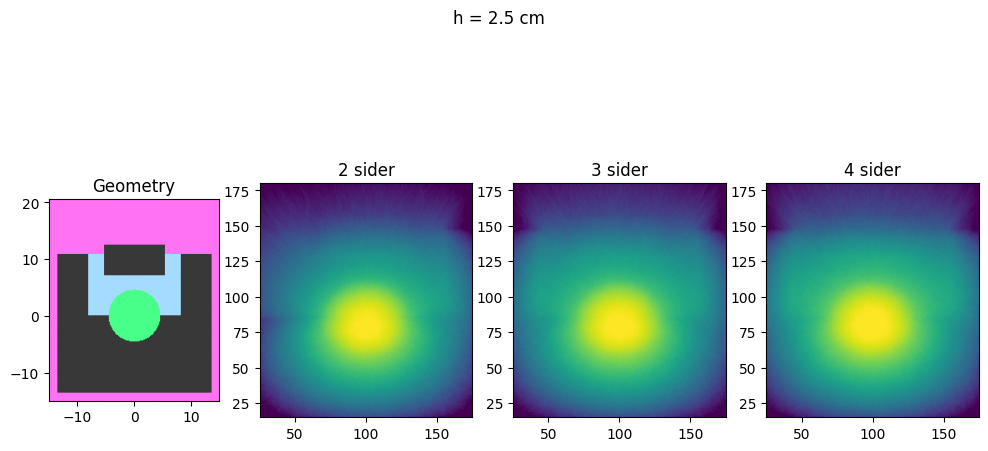

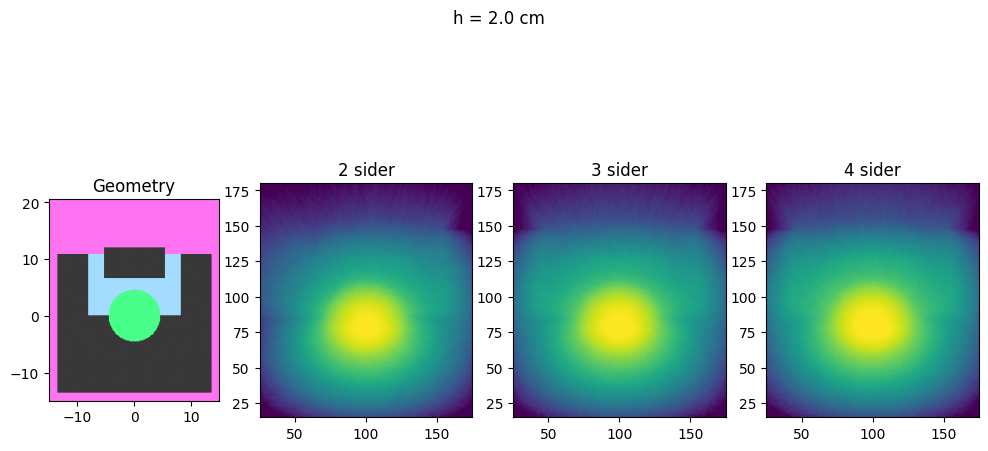

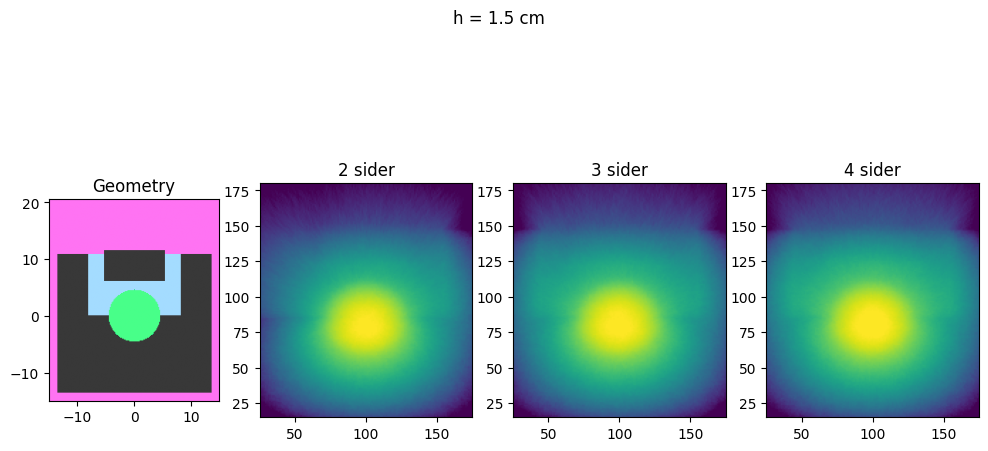

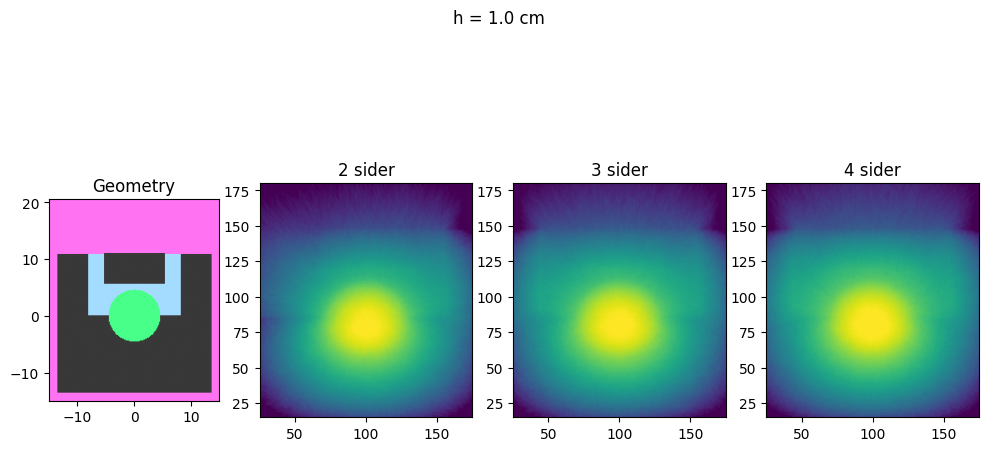

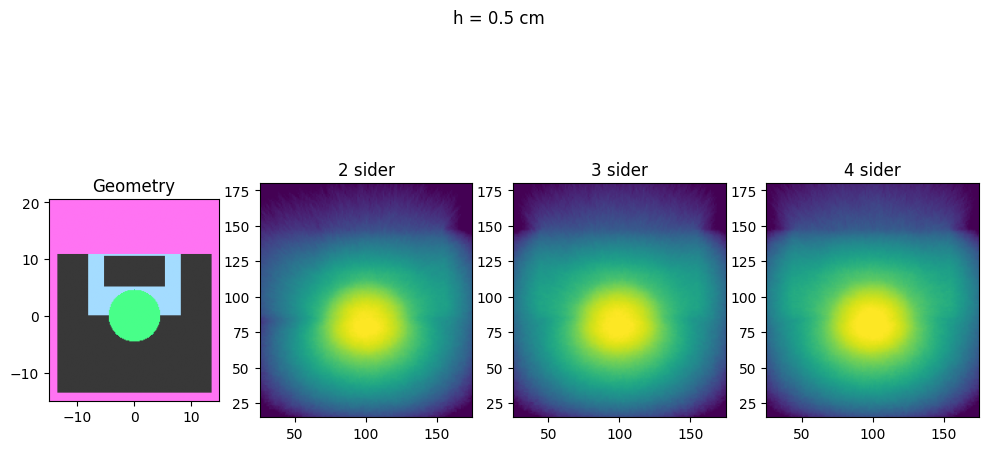

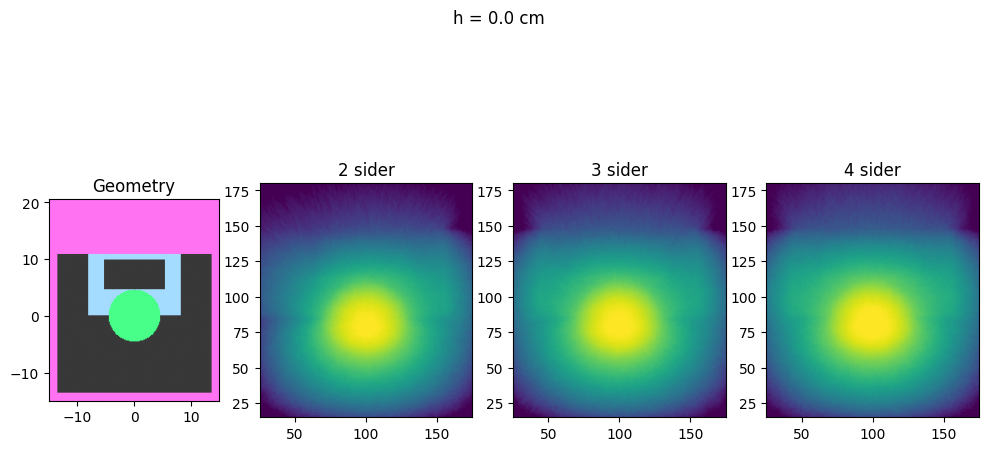

In [ ]:
gifPath = ""
endPath = ""
imgType = "jpeg"

# phis = np.linspace(10, 0, 21)
phis = []
# # phis = [80, 70, 60, 50, 40, 30, 20, 10, 0]


imgNames = []
for i in phis:
    fig, ax = plt.subplots(1, 4, figsize=(12, 6), width_ratios=[0.8, 1, 1, 1])
    
    for nrj, j in enumerate(range(2, 5)):
        r, g, _, _ = makeCore(i, plot=False, sides=j)

        if(j == 3):
            g.plot(axes=ax[0], colors=colors)
            ax[0].set_title(f"Geometry")


        os.system('rm s*h5')
        openmc.run(output=False)
        
        sp = openmc.StatePoint('statepoint.100.h5')
        keff = sp.keff.nominal_value
        keff_error = sp.keff.std_dev
        
        tally = sp.get_tally(scores=['flux'])

        flux = tally.get_slice(scores=['flux'])

        flux.mean.shape = (200, 200)

        
        
        img = ax[nrj+1].imshow(np.log(flux.mean), vmin=-8.5, vmax=-5.5)#maxFlux)
        ax[nrj+1].invert_yaxis()
        ax[nrj+1].set_xlim([25, 175])
        ax[nrj+1].set_ylim([15, 180])
        ax[nrj+1].set_title(f"{j} sider")
        # cbar = plt.colorbar(img, shrink=0.8)
        # cbar.set_label("log(flux) $[ab. units]$")

    fig.suptitle(f"h = {i} cm")#"$k_{eff}$ = " + f"{round(keff,5)} ± {round(keff_error,5)}")
    

    fig.savefig(gifPath + f"/frame{i}.{imgType}")
    imgNames.append(gifPath + f"/frame{i}.{imgType}")


frames = [Image.open(image) for image in imgNames]
frame_one = frames[0]
frame_one.save(endPath + f"/{t.time()}.gif", format="GIF", append_images=frames,
            save_all=True, duration=10, loop=0)

for i in glob.glob(f"{gifPath}/*.{imgType}"):   os.remove(i)  

In [ ]:
# plt.fill_between(phis, keffs+keffsErr, keffs-keffsErr)
# plt.plot(phis, keffs)

In [ ]:
phis = np.linspace(90, 0, 2)
# phis = [80, 70, 60, 50, 40, 30, 20, 10, 0]

if(False): 
    makeTally()
else:
    try:
        os.system('rm tallies.xml')
    except: pass
    
keffs = []
keffsErr = []
for i in phis:
    makeCore(i, plot=False)

    os.system('rm s*h5')
    openmc.run(output=False)
    
    sp = openmc.StatePoint('statepoint.100.h5')
    keffs.append(sp.keff.nominal_value)
    keffsErr.append(sp.keff.std_dev)

keffs = np.array(keffs)
keffsErr = np.array(keffsErr)

/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=10.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=2.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=3.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=6.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=5.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/op

Text(0, 0.5, '$k_{eff}$')

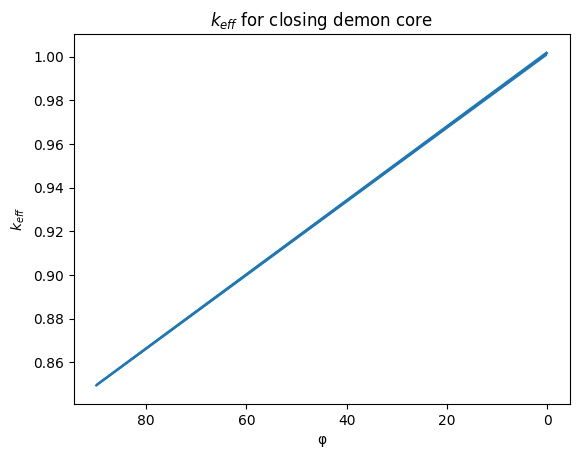

In [ ]:
fig, ax = plt.subplots()
ax.fill_between(phis, keffs+keffsErr, keffs-keffsErr)
ax.plot(phis, keffs)
ax.invert_xaxis()

plt.title("$k_{eff}$ for closing demon core")
plt.xlabel("φ")
plt.ylabel("$k_{eff}$")

# fig.savefig(endPath + "/keff plot.png")


/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=11.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=10.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=2.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=3.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=4.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/o

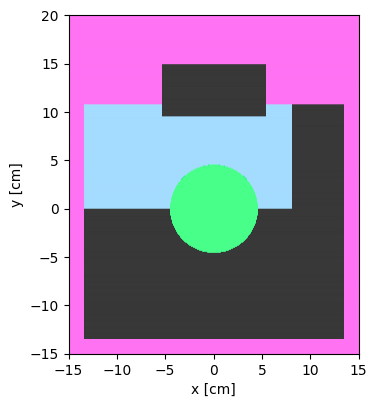

In [14]:
r, g, xs, ys = makeCore(5, plot=True, sides=2)


# a.from_geometry(g)
# a.type = 'voxel'
# a.width = (100., 100., 50.)
# a.pixels = (400, 400, 200)
# openmc.plot_inline()
# type(a)
# ipyImg = a.to_ipython_image()
# ipyImg




In [15]:
a = openmc.VoxelPlot()
a.mask_components = [1]
a.pixels = [400, 400, 400]
a.width = [42, 42, 42]
a.origin = [0, 3, 0]
plotPath = a.to_vtk()
# openmc.plot

In [16]:
import pyvista as pv

volume = pv.read("plot_1.vti")
# volume = pv.read(plotPath)
# print(plotPath)

id = volume.cell_data.get_array("id")  

print(set(id))

pl = pv.Plotter()
id_a = volume.extract_values(11, scalars="id")
id_b = volume.extract_values(2, scalars="id")
id_c = volume.extract_values(5, scalars="id")
# id_b = volume.extract_values(5, scalars="id")

pl.add_mesh(id_a, color="light green", opacity=1)
pl.add_mesh(id_b, color="gray", opacity=0.95)
pl.add_mesh(id_c, color="gray", opacity=0.95)

pl.enable_parallel_projection()
# pl.show_grid()
pl.show()



{np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(10), np.int32(11), np.int32(-2)}


MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


Widget(value='<iframe src="http://localhost:37461/index.html?ui=P_0x749494e89370_1&reconnect=auto" class="pyvi…

In [17]:
# %pip install pyvista[jupyter]

# r = 5
# import numpy as np
# for i in range(100):
#     phi = 2 * np.pi * i/100
#     thisp = openmc.WireframeRayTracePlot(plot_id = 4 + i)
#     thisp.filename = 'frame%s'%(str(i).zfill(3))
#     thisp.look_at = [0, 0, 0]
#     thisp.camera_position = [r * np.cos(phi), r * np.sin(phi), 6 * np.sin(phi)]
#     thisp.pixels = [200, 200]
#     thisp.color_by = 'material'
#     thisp.colorize(root)
#     thisp.set_transparent(root)
#     thisp.xs[fuel] = 1.0
#     thisp.wireframe_domains = [fuel]
#     thisp.wireframe_thickness = 2



# plot = openmc.SolidRayTracePlot()
# plot.pixels = (600, 600)
# plot.camera_position = (10.0, 20.0, -30.0)
# plot.look_at = (4.0, 5.0, 1.0)
# plot.color_by = 'cell'

# # optional. defaults to camera_position
# plot.light_position = (10, 20, 30)

# # controls ambient lighting. Defaults to 10%
# plot.diffuse_fraction = 0.1
# plot.opaque_domains = [coreCell, gap]
# plot.filename = r"/home/alexa/ReaktorFys/Notebooks/RFP/Project/hmm.xml"
# plot.name = "3d.xml"
# p = plot.to_xml_element()

# p.xpath

# # vox_plot = openmc.VoxelPlot(root)
# # vox_plot.type = 'voxel'
# vox_plot.width = (100., 100., 50.)
# vox_plot.pixels = (400, 400, 200)


In [18]:
# openmc.plot_geometry()